# TP2 - Etapa 2 en Google Colab: dataset, preprocesamiento, entrenamiento y comparacion de modelos

Notebook de trabajo de la Etapa 2: analisis del dataset, preprocesamiento, fine-tuning de
ResNet18 (Modelo A, obligatorio), CNN propia (Modelo B, opcional) y estudio comparativo.

El entrenamiento se realiza en Colab para aprovechar la GPU:
**Entorno de ejecucion -> Cambiar tipo de entorno de ejecucion -> GPU (T4)**.

Requisitos previos (en tu fork):
- `train_classifier`, `evaluate_classifier` y `extract_custom_embedding` implementadas
  en `src/lib/services/classifier_service.py` (esta notebook solo las orquesta).

Al finalizar:
- Descargar los checkpoints generados y colocarlos en `models/` de tu entorno local
  (la aplicacion los usa en las pestañas Etapa 1 y 2 del frontend).
- Publicarlos en un link de solo lectura publico para los docentes.
- Entregar esta notebook ejecutada, con sus salidas.

## Equipo
- Alumno 1 :
- Alumno 2 :

## 1. Clonar el repositorio

Si tu fork es privado, genera un token de acceso (GitHub -> Settings -> Developer settings ->
Personal access tokens) y usalo en la URL, o sube un zip del proyecto a Colab/Drive.

In [1]:
# TO-DO: completar con la URL de tu fork.
# Repo privado: https://<TOKEN>@github.com/<usuario>/tuia-dog-recognition-app.git
REPO_URL = "https://github.com/<usuario>/tuia-dog-recognition-app.git"

!git clone $REPO_URL proyecto
%cd proyecto

[WinError 2] The system cannot find the file specified: 'proyecto'
c:\Users\maxir\OneDrive\Documents\tp2_cv\tuia-dog-recognition-app


The system cannot find the file specified.


## 2. Instalar dependencias

Colab ya incluye torch, torchvision, opencv, numpy, scikit-learn y matplotlib;
solo se instala lo que falta.

In [2]:
!pip install -q pydantic-settings python-dotenv kagglehub albumentations


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 3. Configuracion del entorno

En Colab no hay PostgreSQL; la Etapa 2 no usa la base vectorial, por lo que se desactiva
pgvector. La configuracion se define por variables de entorno **antes** de importar `lib`.

In [3]:
import os
import sys
from pathlib import Path

os.environ["USE_PGVECTOR"] = "false"
# Ajusta aca cualquier otra variable (IMAGE_SIZE, EMBEDDING_DIM, paths, etc.)

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from lib.config import settings

import torch
print("dataset_path:", settings.dataset_path)
print("GPU disponible:", torch.cuda.is_available())

dataset_path: data\dataset
GPU disponible: False


## 4. Descargar el dataset

In [4]:
!python scripts/download_dataset.py
!ls data/dataset

Descargando gpiosenka/70-dog-breedsimage-data-set ...
Ya existe, se omite: C:\Users\maxir\OneDrive\Documents\tp2_cv\tuia-dog-recognition-app\data\dataset\dogs.csv
Ya existe, se omite: C:\Users\maxir\OneDrive\Documents\tp2_cv\tuia-dog-recognition-app\data\dataset\test
Ya existe, se omite: C:\Users\maxir\OneDrive\Documents\tp2_cv\tuia-dog-recognition-app\data\dataset\train
Ya existe, se omite: C:\Users\maxir\OneDrive\Documents\tp2_cv\tuia-dog-recognition-app\data\dataset\valid
Dataset disponible en C:\Users\maxir\OneDrive\Documents\tp2_cv\tuia-dog-recognition-app\data\dataset


'ls' is not recognized as an internal or external command,
operable program or batch file.


## 5. Analisis del dataset

TO-DO:
- Analizar la distribucion de clases y documentar la cantidad de imagenes por raza.
- Definir los conjuntos de entrenamiento, validacion y prueba.
- Construir un conjunto independiente para evaluacion (ej: imagenes descargadas de internet).
- Filtrar imagenes de baja calidad (documentar el criterio).

C:\Users\maxir\AppData\Local\Temp\ipykernel_3252\1602506731.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(sorted_classes.keys())[:20], y=list(sorted_classes.values())[:20], palette="viridis")


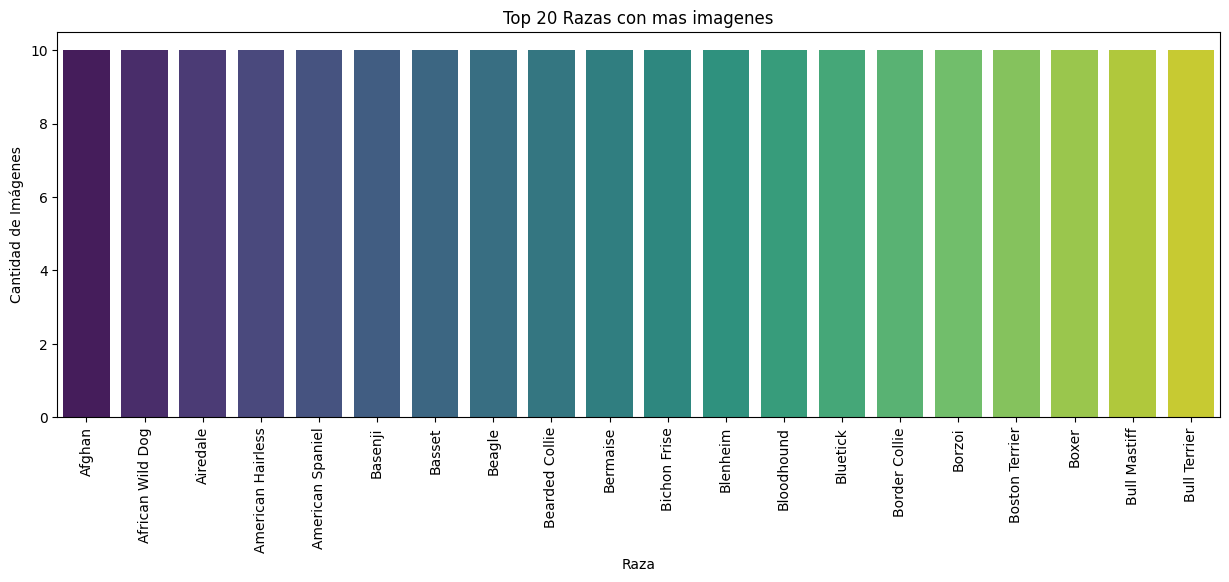

Total de clases: 70
Total de imagenes: 700


In [5]:
## TO-DO: analisis exploratorio del dataset (distribucion de clases, imagenes por raza, splits).

import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split

#dataset_path = Path(settings.dataset_path)
dataset_path = Path("data/dataset/test")

#contar imagenes por clase
class_counts = {}
for breed_dir in dataset_path.iterdir():
    if breed_dir.is_dir():
        class_counts[breed_dir.name] = len(list(breed_dir.glob('*.jpg')))

sorted_classes = dict(sorted(class_counts.items(), key=lambda item: item[1], reverse=True)) #ordenar

plt.figure(figsize=(15, 5))
sns.barplot(x=list(sorted_classes.keys())[:20], y=list(sorted_classes.values())[:20], palette="viridis")
plt.xticks(rotation=90)
plt.title("Top 20 Razas con mas imagenes")
plt.ylabel("Cantidad de Imágenes")
plt.xlabel("Raza")
plt.show()

print(f"Total de clases: {len(class_counts)}")
print(f"Total de imagenes: {sum(class_counts.values())}")

## 6. Preprocesamiento

TO-DO: definir y justificar resize, normalizacion y data augmentation (horizontal flip,
rotacion, blur, variaciones de brillo y contraste, ruido).

In [6]:
## TO-DO: transformaciones de preprocesamiento y data augmentation (con ejemplos visuales).

from torchvision import transforms

# Transformaciones con data augmentation para train
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(p=0.5), # 50% de probabilidad de rotar horizontalmente 
    transforms.RandomRotation(15),          # Rotación leve
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Variación de luz
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transformaciones para validacion y test
val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## 7. Modelo A (obligatorio): fine-tuning de ResNet18

`train_classifier` debe guardar el checkpoint en `models/resnet18_finetuned.pth`
(o el nombre configurado en RESNET18_MODEL_NAME). Documentar los hiperparametros
utilizados (learning rate, batch size, epochs, optimizador, scheduler).

In [7]:
from lib.bootstrap import build_classifier

classifier = build_classifier(settings)
classifier.set_active_model("resnet18_finetuned")
classifier.train_classifier()

Epoch 1/30 | Train Loss: 2.7604 Acc: 0.2815 | Val Loss: 2.0641 Acc: 0.4529
Epoch 2/30 | Train Loss: 2.0110 Acc: 0.4455 | Val Loss: 1.3613 Acc: 0.6414
Epoch 3/30 | Train Loss: 1.6745 Acc: 0.5262 | Val Loss: 1.2256 Acc: 0.7029
Epoch 4/30 | Train Loss: 1.5155 Acc: 0.5663 | Val Loss: 1.1259 Acc: 0.7543
Epoch 5/30 | Train Loss: 1.3904 Acc: 0.5968 | Val Loss: 1.0756 Acc: 0.7386
Epoch 6/30 | Train Loss: 1.3010 Acc: 0.6241 | Val Loss: 0.9506 Acc: 0.7929
Epoch 7/30 | Train Loss: 1.2564 Acc: 0.6443 | Val Loss: 0.9002 Acc: 0.7929
Epoch 8/30 | Train Loss: 1.1798 Acc: 0.6573 | Val Loss: 0.9066 Acc: 0.7971
Epoch 9/30 | Train Loss: 1.1205 Acc: 0.6720 | Val Loss: 0.9620 Acc: 0.8200
Epoch 10/30 | Train Loss: 1.0731 Acc: 0.6853 | Val Loss: 1.0211 Acc: 0.7800
Epoch 11/30 | Train Loss: 1.0087 Acc: 0.7058 | Val Loss: 0.9933 Acc: 0.8371
Epoch 12/30 | Train Loss: 1.0034 Acc: 0.7050 | Val Loss: 0.9466 Acc: 0.8471
Epoch 13/30 | Train Loss: 0.9724 Acc: 0.7182 | Val Loss: 1.0723 Acc: 0.8429
Epoch 14/30 | Train L

In [8]:
metrics_a = classifier.evaluate_classifier()
metrics_a

{'accuracy': 0.9085714285714286,
 'precision': 0.9232926597212311,
 'recall': 0.9085714285714286,
 'specificity': 0.9986749482387183,
 'f1': 0.9055935587977968,
 'confusion_matrix': [[9,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   1,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0],
  [0,
   9,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   1,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
  

### Curvas de entrenamiento y matriz de confusion (Modelo A)

TO-DO: graficar las curvas de entrenamiento/validacion y la matriz de confusion.

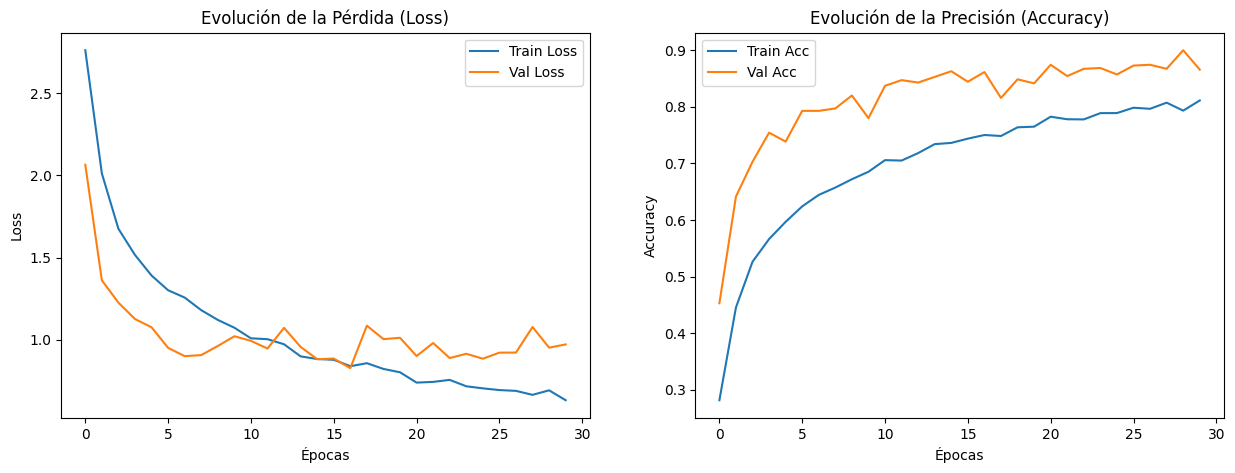

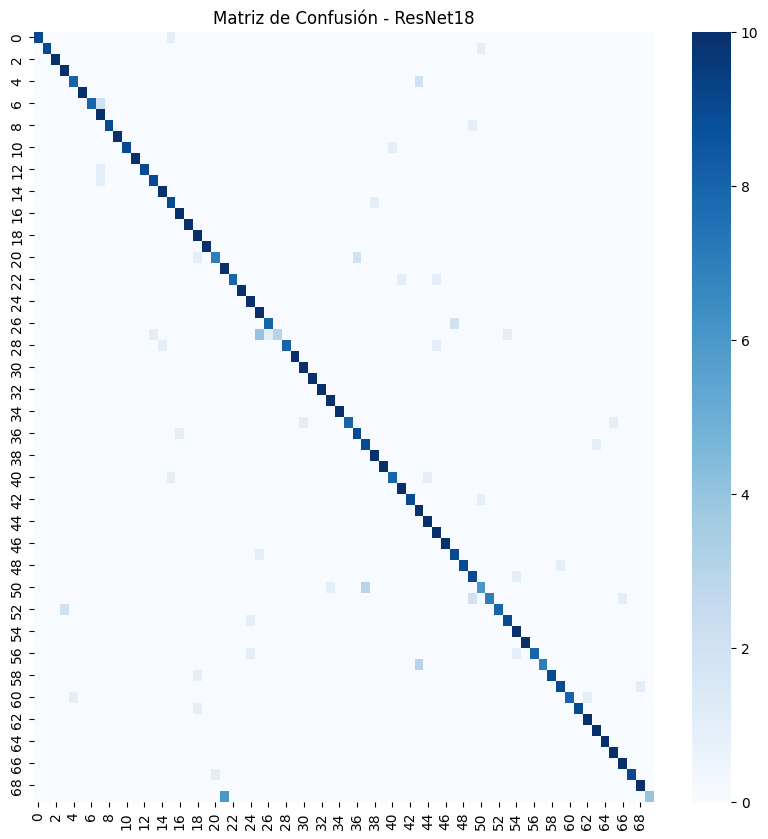

In [9]:
## TO-DO: curvas de entrenamiento y matriz de confusion del Modelo A.

history = classifier.history 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Curva de Loss
ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'], label='Val Loss')
ax1.set_title('Evolución de la Pérdida (Loss)')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Loss')
ax1.legend()

# Curva de Accuracy
ax2.plot(history['train_acc'], label='Train Acc')
ax2.plot(history['val_acc'], label='Val Acc')
ax2.set_title('Evolución de la Precisión (Accuracy)')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.show()

cm = metrics_a['confusion_matrix']
plt.figure(figsize=(10,10))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Matriz de Confusión - ResNet18')
plt.show()

## 8. Modelo B (opcional, recomendado): CNN propia

`train_classifier` con el modelo activo `cnn_custom` debe guardar el checkpoint en
`models/cnn_custom.pth` (o el nombre configurado en CNN_CUSTOM_MODEL_NAME).

In [10]:
classifier.set_active_model("cnn_custom")
classifier.train_classifier()
metrics_b = classifier.evaluate_classifier()
metrics_b

Epoch 1/30 | Train Loss: 3.9072 Acc: 0.0678 | Val Loss: 3.9075 Acc: 0.0714
Epoch 2/30 | Train Loss: 3.6506 Acc: 0.1004 | Val Loss: 3.3528 Acc: 0.1429
Epoch 3/30 | Train Loss: 3.4797 Acc: 0.1315 | Val Loss: 3.1980 Acc: 0.1371
Epoch 4/30 | Train Loss: 3.3231 Acc: 0.1606 | Val Loss: 3.2465 Acc: 0.1614
Epoch 5/30 | Train Loss: 3.2103 Acc: 0.1790 | Val Loss: 3.0411 Acc: 0.2229
Epoch 6/30 | Train Loss: 3.0898 Acc: 0.1992 | Val Loss: 2.7758 Acc: 0.2714
Epoch 7/30 | Train Loss: 2.9728 Acc: 0.2263 | Val Loss: 2.6456 Acc: 0.3157
Epoch 8/30 | Train Loss: 2.9401 Acc: 0.2347 | Val Loss: 2.6208 Acc: 0.3071
Epoch 9/30 | Train Loss: 2.8436 Acc: 0.2503 | Val Loss: 2.5565 Acc: 0.3229
Epoch 10/30 | Train Loss: 2.7628 Acc: 0.2658 | Val Loss: 2.6881 Acc: 0.2786
Epoch 11/30 | Train Loss: 2.7073 Acc: 0.2806 | Val Loss: 2.5769 Acc: 0.3271
Epoch 12/30 | Train Loss: 2.6169 Acc: 0.3017 | Val Loss: 2.3015 Acc: 0.3743
Epoch 13/30 | Train Loss: 2.5369 Acc: 0.3199 | Val Loss: 2.1966 Acc: 0.3829
Epoch 14/30 | Train L

{'accuracy': 0.6428571428571429,
 'precision': 0.6988000491571921,
 'recall': 0.6428571428571429,
 'specificity': 0.9948240165617053,
 'f1': 0.626344945086258,
 'confusion_matrix': [[5,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   2,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   1,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   1,
   0,
   0,
   0,
   0,
   0,
   1,
   0,
   0,
   0],
  [0,
   9,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   1,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   

## 9. Estudio comparativo

TO-DO (pequeño estudio de la Etapa 2):
- Comparar los modelos entrenados: accuracy, precision, recall, specificity, F1.
- Analizar las clases con peor desempeño (falsos positivos / falsos negativos).
- Discutir trade-offs (performance vs costo computacional).
- Copiar las conclusiones al informe (`informe.ipynb`).

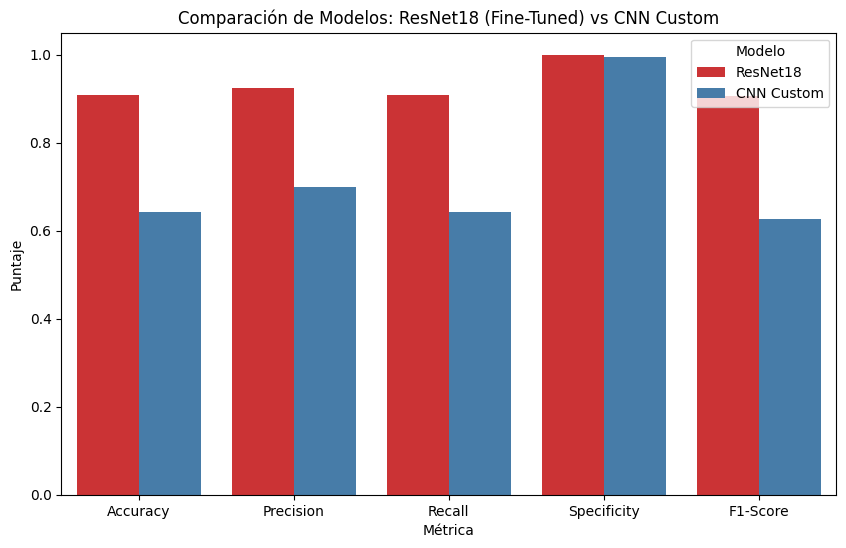


Top 5 razas que más le costó clasificar a ResNet18:
    Raza  Desempeño (Recall)
  Cocker                 0.3
  Yorkie                 0.4
Malinois                 0.6
 Maltese                 0.7
  Poodle                 0.7

Top 5 razas que más le costó clasificar a CNN Custom:
            Raza  Desempeño (Recall)
          Cocker                 0.1
            Chow                 0.1
        Cockapoo                 0.1
Golden Retriever                 0.1
       Greyhound                 0.2


In [11]:
## TO-DO: comparacion entre modelos y analisis de errores.
import pandas as pd

# GRÁFICO COMPARATIVO DE MÉTRICAS
df_metrics = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score'],
    'ResNet18': [metrics_a['accuracy'], metrics_a['precision'], metrics_a['recall'], metrics_a['specificity'], metrics_a['f1']],
    'CNN Custom': [metrics_b['accuracy'], metrics_b['precision'], metrics_b['recall'], metrics_b['specificity'], metrics_b['f1']]
})

df_melted = df_metrics.melt(id_vars='Métrica', var_name='Modelo', value_name='Puntaje')

plt.figure(figsize=(10, 6))
sns.barplot(x='Métrica', y='Puntaje', hue='Modelo', data=df_melted, palette='Set1')
plt.title('Comparación de Modelos: ResNet18 (Fine-Tuned) vs CNN Custom')
plt.ylim(0, 1.05)
plt.show()

# ANÁLISIS DE PEORES CLASES (Falsos Negativos)
class_names = classifier.class_names 

def analizar_peores_clases(cm_list, nombre_modelo):
    cm = np.array(cm_list)
    recalls = np.diag(cm) / (np.sum(cm, axis=1) + 1e-9) 
    
    df_worst = pd.DataFrame({
        'Raza': class_names,
        'Desempeño (Recall)': recalls
    }).sort_values(by='Desempeño (Recall)')
    
    print(f"\nTop 5 razas que más le costó clasificar a {nombre_modelo}:")
    print(df_worst.head(5).to_string(index=False))

analizar_peores_clases(metrics_a['confusion_matrix'], "ResNet18")
analizar_peores_clases(metrics_b['confusion_matrix'], "CNN Custom")

## 10. Descargar los checkpoints

Descargalos y colocalos en `models/` de tu entorno local para que la aplicacion los use
(pestañas Etapa 1 y 2 del frontend). Recorda publicarlos en un link de solo lectura publico.

In [12]:
!ls -lh models/

try:
    from google.colab import files

    files.download(str(settings.model_path / settings.resnet18_model_name))
    # files.download(str(settings.model_path / settings.cnn_custom_model_name))
except ImportError:
    print("Fuera de Colab: los checkpoints quedan en models/")

Fuera de Colab: los checkpoints quedan en models/


'ls' is not recognized as an internal or external command,
operable program or batch file.
